In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv


In [2]:
"""
==============================================================================
NOTEBOOK 6: DEEP LEARNING WITH DRAGONNET (PyTorch)
==============================================================================

Project: Industrial-Scale Uplift Modeling for Ad Spend Optimization
Goal:    Implement DragonNet — a neural architecture specifically designed
         for treatment effect estimation (Shi, Blei, Veitch — NeurIPS 2019).
         
         Architecture:
         • Shared representation layer (encodes confounders)
         • Two outcome heads: Y(0) and Y(1)
         • Propensity head: T
         • Targeted regularization loss

Author:  Anurag Jain (M.Sc. Economics, IGIDR)
==============================================================================
"""

import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Save
import joblib

# Display
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# GPU Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  GPU not available — training will be slow on CPU")
    print("    Enable GPU: Settings → Accelerator → GPU P100")

✅ PyTorch version: 2.10.0+cu128
✅ Device: cuda
✅ GPU: Tesla T4
✅ GPU Memory: 15.6 GB


In [3]:
# ============================================================================
# LOAD DATA
# ============================================================================

DATA_PATH = '/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv'
# ⚠️ Update path if different

print("📥 Loading and sampling data...")

chunk_size = 1_000_000
sample_fraction = 0.15
sampled_chunks = []

chunks = pd.read_csv(DATA_PATH, chunksize=chunk_size)
for i, chunk in enumerate(chunks):
    sampled = (
        chunk.groupby(['treatment', 'conversion'], group_keys=False)
        .apply(lambda x: x.sample(frac=sample_fraction, random_state=42))
    )
    sampled_chunks.append(sampled)

df = pd.concat(sampled_chunks, ignore_index=True)

# Memory optimization
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print(f"✅ Dataset: {len(df):,} rows")

📥 Loading and sampling data...
✅ Dataset: 2,096,938 rows


In [4]:
# ============================================================================
# PREPARE FEATURES & SCALE FOR NEURAL NETWORK
# ============================================================================

feature_cols = [f'f{i}' for i in range(12)]

X = df[feature_cols].values.astype(np.float32)
T = df['treatment'].values.astype(np.float32)
Y = df['conversion'].values.astype(np.float32)

# Stratified split
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.3, random_state=42,
    stratify=df[['treatment', 'conversion']]
)

X_train, X_test = X[train_idx], X[test_idx]
T_train, T_test = T[train_idx], T[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

# ⚡ Scale features (CRITICAL for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
T_train_t = torch.tensor(T_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
T_test_t = torch.tensor(T_test, dtype=torch.float32).to(device)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).to(device)

print(f"✅ Train set: {X_train_t.shape}")
print(f"✅ Test set: {X_test_t.shape}")
print(f"✅ Treatment rate: {T_train.mean()*100:.1f}%")
print(f"✅ Conversion rate: {Y_train.mean()*100:.3f}%")
print(f"✅ Data on device: {X_train_t.device}")

✅ Train set: torch.Size([1467856, 12])
✅ Test set: torch.Size([629082, 12])
✅ Treatment rate: 85.0%
✅ Conversion rate: 0.292%
✅ Data on device: cuda:0


In [5]:
# ============================================================================
# DRAGONNET ARCHITECTURE
# ============================================================================
# Reference: Shi, Blei, Veitch (NeurIPS 2019)
# 
# Structure:
#   X → [Shared Layers] → Representation Φ(X)
#                              ├─→ y0_head → Predicted Y if T=0
#                              ├─→ y1_head → Predicted Y if T=1
#                              └─→ t_head  → Propensity P(T=1|X)

class DragonNet(nn.Module):
    """
    DragonNet: Neural network for treatment effect estimation
    """
    def __init__(self, input_dim, hidden_dim=200):
        super(DragonNet, self).__init__()
        
        # Shared representation Φ(X)
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU()
        )
        
        # Outcome head for control (Y | T=0, X)
        self.y0_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()  # Output probability of conversion
        )
        
        # Outcome head for treatment (Y | T=1, X)
        self.y1_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()  # Output probability of conversion
        )
        
        # Propensity head P(T=1 | X)
        self.t_head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
        # Targeted regularization parameter (epsilon)
        self.epsilon = nn.Parameter(torch.tensor(0.0))
    
    def forward(self, x):
        # Shared representation
        phi = self.shared(x)
        
        # Three outputs
        y0_pred = self.y0_head(phi).squeeze(-1)
        y1_pred = self.y1_head(phi).squeeze(-1)
        t_pred = self.t_head(phi).squeeze(-1)
        
        return y0_pred, y1_pred, t_pred, self.epsilon


# Test the architecture
test_model = DragonNet(input_dim=12).to(device)
print("✅ DragonNet architecture defined")
print(f"\n📋 Model structure:")
print(test_model)

# Parameter count
total_params = sum(p.numel() for p in test_model.parameters())
print(f"\n📊 Total parameters: {total_params:,}")

del test_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

✅ DragonNet architecture defined

📋 Model structure:
DragonNet(
  (shared): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=200, out_features=200, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=200, out_features=200, bias=True)
    (5): ELU(alpha=1.0)
  )
  (y0_head): Sequential(
    (0): Linear(in_features=200, out_features=100, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=100, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (y1_head): Sequential(
    (0): Linear(in_features=200, out_features=100, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=100, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (t_head): Sequential(
    (0): Linear(in_features=200, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

📊 Total parameters: 123,604


In [6]:
# ============================================================================
# DRAGONNET LOSS FUNCTION
# ============================================================================
# Loss = Outcome Loss + α × Propensity Loss + β × Targeted Regularization
#
# - Outcome Loss: How well we predict Y for treated/control
# - Propensity Loss: How well we predict T (binary cross-entropy)
# - Targeted Reg: Forces network to model treatment effect explicitly

def dragonnet_loss(y0_pred, y1_pred, t_pred, epsilon, y_true, t_true, 
                   alpha=1.0, beta=1.0, eps_clip=1e-4):
    """
    DragonNet loss with targeted regularization
    
    Args:
        y0_pred, y1_pred: Predicted outcomes for T=0 and T=1
        t_pred: Predicted treatment propensity
        epsilon: Targeted regularization parameter
        y_true, t_true: Actual outcomes and treatments
        alpha: Weight for propensity loss
        beta: Weight for targeted regularization
    """
    # 1. OUTCOME LOSS (binary cross-entropy)
    # Use y0_pred for control samples, y1_pred for treated samples
    y_pred = t_true * y1_pred + (1 - t_true) * y0_pred
    y_pred = torch.clamp(y_pred, eps_clip, 1 - eps_clip)
    outcome_loss = nn.functional.binary_cross_entropy(y_pred, y_true)
    
    # 2. PROPENSITY LOSS (binary cross-entropy for treatment)
    t_pred_clipped = torch.clamp(t_pred, eps_clip, 1 - eps_clip)
    propensity_loss = nn.functional.binary_cross_entropy(t_pred_clipped, t_true)
    
    # 3. TARGETED REGULARIZATION
    # Forces the model to explicitly model the treatment effect
    # Reference: Shi et al. 2019 - Targeted Regularization section
    h = (t_true / t_pred_clipped) - ((1 - t_true) / (1 - t_pred_clipped))
    y_perturbed = y_pred + epsilon * h
    y_perturbed = torch.clamp(y_perturbed, eps_clip, 1 - eps_clip)
    targeted_reg = nn.functional.binary_cross_entropy(y_perturbed, y_true)
    
    # Combined loss
    total_loss = outcome_loss + alpha * propensity_loss + beta * targeted_reg
    
    return total_loss, outcome_loss, propensity_loss, targeted_reg

print("✅ DragonNet loss function defined")

✅ DragonNet loss function defined


In [7]:
# ============================================================================
# TRAIN DRAGONNET
# ============================================================================

# Hyperparameters
INPUT_DIM = 12
HIDDEN_DIM = 200
BATCH_SIZE = 4096   # Large batch for stable gradients with rare events
EPOCHS = 30
LEARNING_RATE = 1e-3
ALPHA = 1.0          # Propensity loss weight
BETA = 0.5           # Targeted regularization weight

print("="*60)
print(f"🚀 Training DragonNet at {time.strftime('%H:%M:%S')}...")
print("="*60)
print(f"   Hidden dim: {HIDDEN_DIM}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Device: {device}")

# Initialize model
model = DragonNet(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Create DataLoader
train_dataset = TensorDataset(X_train_t, T_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Training history
history = {'total_loss': [], 'outcome_loss': [], 
           'propensity_loss': [], 'targeted_reg': []}

start = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = {'total': 0, 'outcome': 0, 'propensity': 0, 'reg': 0}
    n_batches = 0
    
    for batch_x, batch_t, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        y0_pred, y1_pred, t_pred, epsilon = model(batch_x)
        
        # Compute loss
        total_loss, out_loss, prop_loss, reg_loss = dragonnet_loss(
            y0_pred, y1_pred, t_pred, epsilon,
            batch_y, batch_t, alpha=ALPHA, beta=BETA
        )
        
        # Backward pass
        total_loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Track losses
        epoch_losses['total'] += total_loss.item()
        epoch_losses['outcome'] += out_loss.item()
        epoch_losses['propensity'] += prop_loss.item()
        epoch_losses['reg'] += reg_loss.item()
        n_batches += 1
    
    # Average losses
    for key in epoch_losses:
        epoch_losses[key] /= n_batches
    
    history['total_loss'].append(epoch_losses['total'])
    history['outcome_loss'].append(epoch_losses['outcome'])
    history['propensity_loss'].append(epoch_losses['propensity'])
    history['targeted_reg'].append(epoch_losses['reg'])
    
    # Learning rate scheduler
    scheduler.step(epoch_losses['total'])
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"   Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Total: {epoch_losses['total']:.5f} | "
              f"Outcome: {epoch_losses['outcome']:.5f} | "
              f"Prop: {epoch_losses['propensity']:.5f} | "
              f"Reg: {epoch_losses['reg']:.5f} | "
              f"LR: {current_lr:.6f}")

elapsed = (time.time() - start) / 60
print(f"\n✅ DragonNet trained in {elapsed:.1f} minutes")

🚀 Training DragonNet at 07:09:43...
   Hidden dim: 200
   Batch size: 4096
   Epochs: 30
   Learning rate: 0.001
   Device: cuda
   Epoch  1/30 | Total: 0.46190 | Outcome: 0.02331 | Prop: 0.42663 | Reg: 0.02391 | LR: 0.001000
   Epoch  5/30 | Total: 0.44086 | Outcome: 0.01199 | Prop: 0.42275 | Reg: 0.01224 | LR: 0.001000
   Epoch 10/30 | Total: 0.44058 | Outcome: 0.01191 | Prop: 0.42264 | Reg: 0.01205 | LR: 0.001000
   Epoch 15/30 | Total: 0.44035 | Outcome: 0.01184 | Prop: 0.42252 | Reg: 0.01197 | LR: 0.000500
   Epoch 20/30 | Total: 0.44019 | Outcome: 0.01178 | Prop: 0.42249 | Reg: 0.01184 | LR: 0.000250
   Epoch 25/30 | Total: 0.44018 | Outcome: 0.01177 | Prop: 0.42248 | Reg: 0.01186 | LR: 0.000250
   Epoch 30/30 | Total: 0.44006 | Outcome: 0.01173 | Prop: 0.42245 | Reg: 0.01176 | LR: 0.000125

✅ DragonNet trained in 10.8 minutes


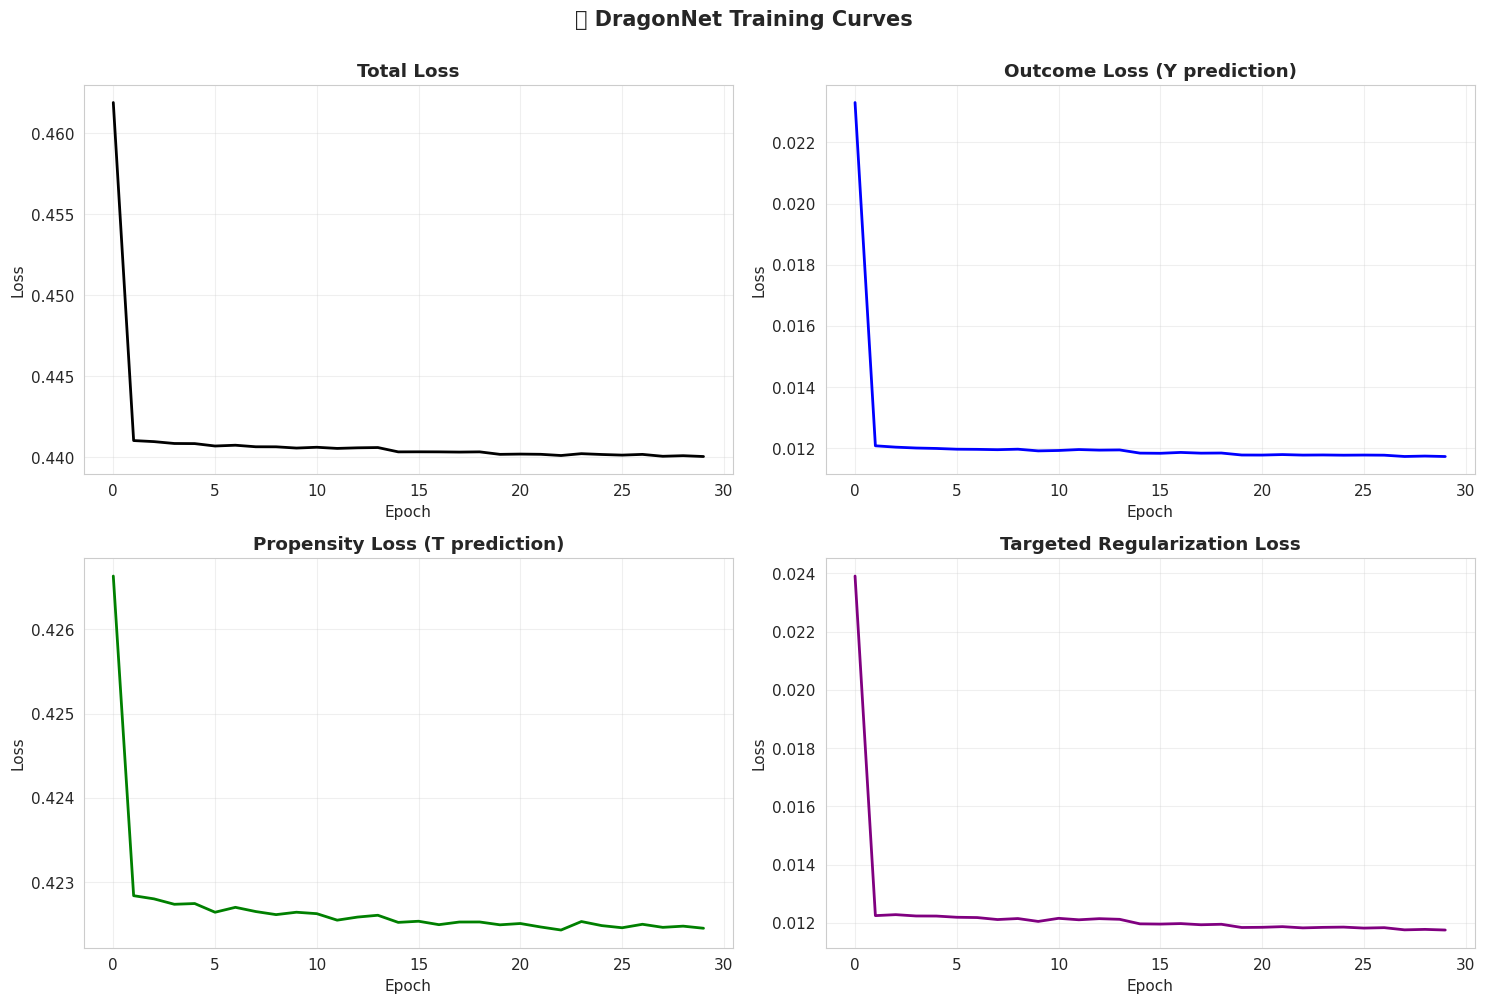

💡 Healthy training: All losses should decrease and stabilize


In [8]:
# ============================================================================
# VISUALIZE TRAINING CURVES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total loss
axes[0, 0].plot(history['total_loss'], color='black', linewidth=2)
axes[0, 0].set_title('Total Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Outcome loss
axes[0, 1].plot(history['outcome_loss'], color='blue', linewidth=2)
axes[0, 1].set_title('Outcome Loss (Y prediction)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

# Propensity loss
axes[1, 0].plot(history['propensity_loss'], color='green', linewidth=2)
axes[1, 0].set_title('Propensity Loss (T prediction)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

# Targeted regularization
axes[1, 1].plot(history['targeted_reg'], color='purple', linewidth=2)
axes[1, 1].set_title('Targeted Regularization Loss', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('🧠 DragonNet Training Curves', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('dragonnet_training.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 Healthy training: All losses should decrease and stabilize")

In [9]:
# ============================================================================
# PREDICT TREATMENT EFFECTS
# ============================================================================

print("🔮 Predicting treatment effects on test set...")

model.eval()
with torch.no_grad():
    # Predict for ALL test users
    y0_pred, y1_pred, t_pred, _ = model(X_test_t)
    
    # Treatment effect = Y(1) - Y(0)
    dn_uplift = (y1_pred - y0_pred).cpu().numpy()
    
    # Also get propensity scores for analysis
    dn_propensity = t_pred.cpu().numpy()

# Calculate ATE
dn_ate = dn_uplift.mean()

print(f"\n✅ Predictions complete")
print(f"   Average Treatment Effect (ATE): {dn_ate*100:+.4f} pp")
print(f"   Min uplift: {dn_uplift.min()*100:+.4f} pp")
print(f"   Max uplift: {dn_uplift.max()*100:+.4f} pp")
print(f"   Std uplift: {dn_uplift.std()*100:.4f} pp")
print(f"\n📊 Propensity statistics:")
print(f"   Mean propensity: {dn_propensity.mean():.4f}")
print(f"   Min propensity: {dn_propensity.min():.4f}")
print(f"   Max propensity: {dn_propensity.max():.4f}")

🔮 Predicting treatment effects on test set...

✅ Predictions complete
   Average Treatment Effect (ATE): +0.0879 pp
   Min uplift: -0.6025 pp
   Max uplift: +21.7498 pp
   Std uplift: 0.6637 pp

📊 Propensity statistics:
   Mean propensity: 0.8519
   Min propensity: 0.8289
   Max propensity: 0.9369


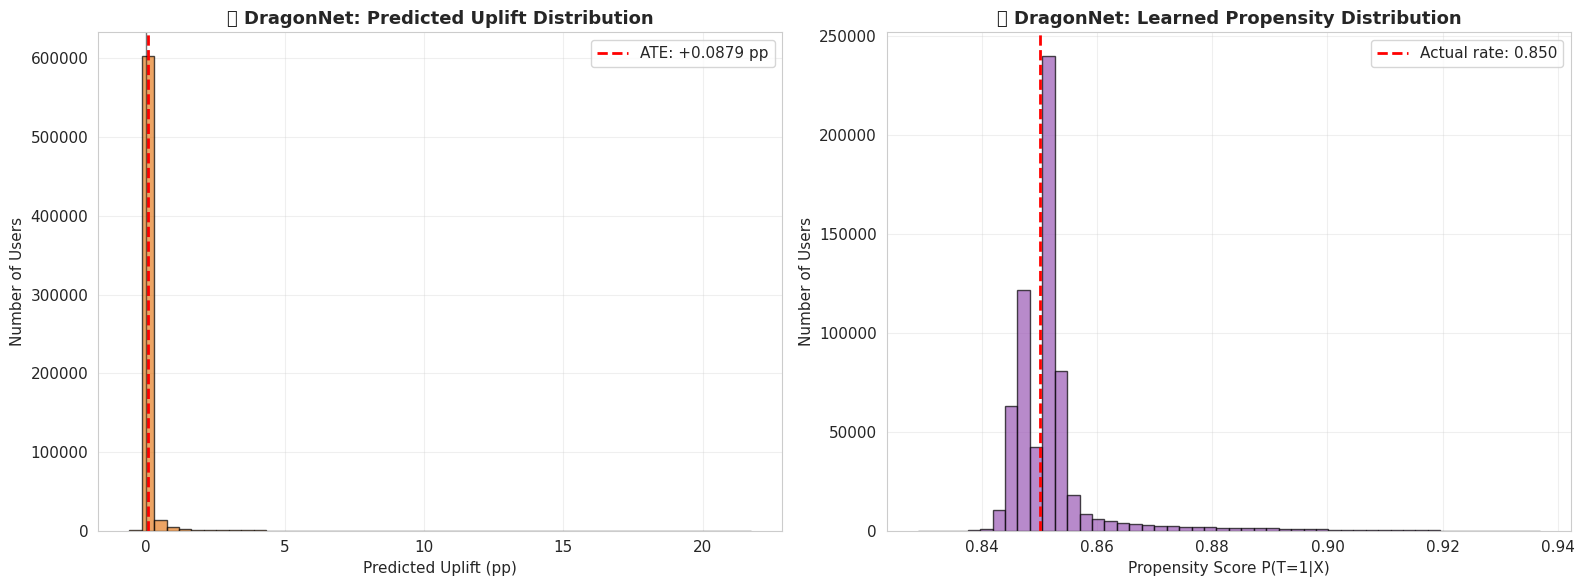

In [10]:
# ============================================================================
# VISUALIZE DRAGONNET UPLIFT DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Uplift distribution
axes[0].hist(dn_uplift*100, bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
axes[0].axvline(dn_ate*100, color='red', linestyle='--', linewidth=2, 
                label=f'ATE: {dn_ate*100:+.4f} pp')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[0].set_title('🧠 DragonNet: Predicted Uplift Distribution', 
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted Uplift (pp)')
axes[0].set_ylabel('Number of Users')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Propensity score distribution
axes[1].hist(dn_propensity, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].axvline(T_test.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Actual rate: {T_test.mean():.3f}')
axes[1].set_title('🧠 DragonNet: Learned Propensity Distribution',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Propensity Score P(T=1|X)')
axes[1].set_ylabel('Number of Users')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dragonnet_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

🎯 DRAGONNET CUSTOMER SEGMENTATION
                       segment  n_users  pct_of_users  avg_uplift_score  actual_uplift_pp
      🎯 Persuadables (Top 10%)  62909.0       10.0001            0.8377            0.7877
  ✅ Likely Responders (10-30%) 125816.0       19.9999            0.0182           -0.0032
            😐 Neutral (30-70%) 251632.0       39.9999            0.0027            0.0069
        ❌ Lost Causes (70-90%) 125816.0       19.9999            0.0006           -0.0049
⚠️ Do-Not-Disturb (Bottom 10%)  62909.0       10.0001           -0.0072            0.0919


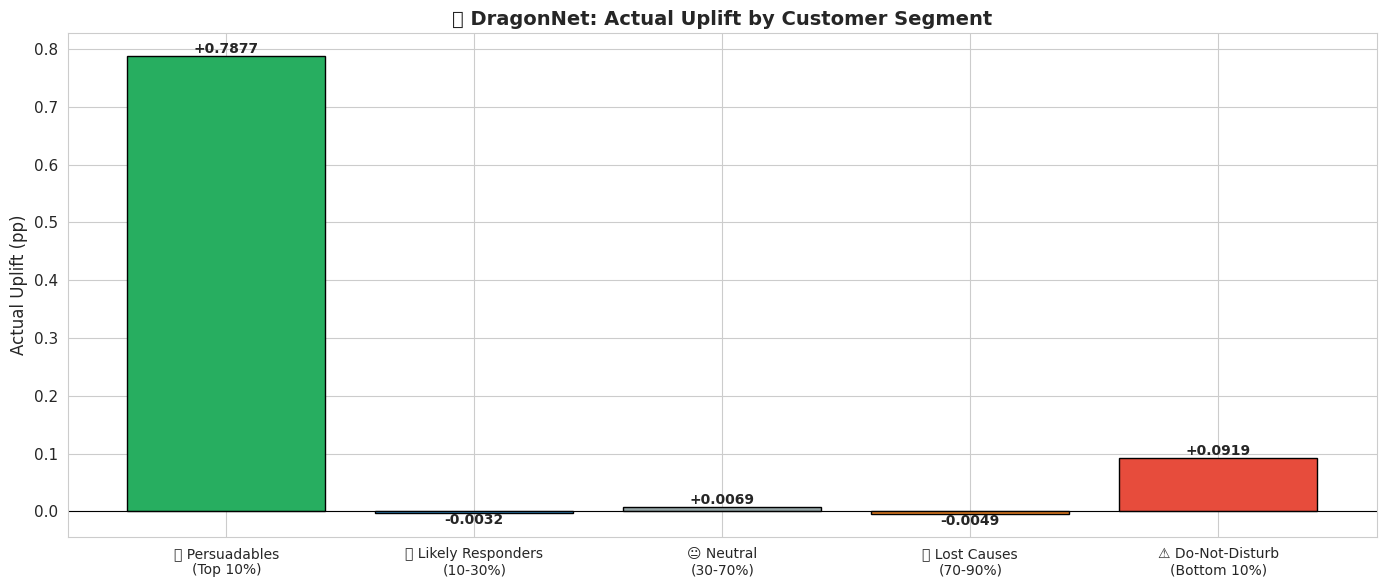

In [11]:
# ============================================================================
# SEGMENT USERS USING DRAGONNET UPLIFT SCORES
# ============================================================================

segments_df = pd.DataFrame({
    'uplift_score': dn_uplift,
    'treatment': T_test,
    'conversion': Y_test
})

# Use rank-based qcut to ensure balanced segments
segments_df['decile'] = pd.qcut(
    segments_df['uplift_score'].rank(method='first'),
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

def decile_to_segment(decile):
    if decile == 'D10':
        return '🎯 Persuadables (Top 10%)'
    elif decile in ['D8', 'D9']:
        return '✅ Likely Responders (10-30%)'
    elif decile in ['D4', 'D5', 'D6', 'D7']:
        return '😐 Neutral (30-70%)'
    elif decile in ['D2', 'D3']:
        return '❌ Lost Causes (70-90%)'
    else:
        return '⚠️ Do-Not-Disturb (Bottom 10%)'

segments_df['segment'] = segments_df['decile'].apply(decile_to_segment)

# Calculate segment statistics
segment_stats = segments_df.groupby('segment').apply(
    lambda x: pd.Series({
        'n_users': len(x),
        'avg_uplift_score': x['uplift_score'].mean() * 100,
        'actual_treatment_conv': x[x['treatment']==1]['conversion'].mean() * 100
                                  if (x['treatment']==1).any() else np.nan,
        'actual_control_conv': x[x['treatment']==0]['conversion'].mean() * 100
                                if (x['treatment']==0).any() else np.nan,
    })
).reset_index()

segment_stats['actual_uplift_pp'] = (
    segment_stats['actual_treatment_conv'] - segment_stats['actual_control_conv']
)
segment_stats['pct_of_users'] = segment_stats['n_users'] / segment_stats['n_users'].sum() * 100

display_order = [
    '🎯 Persuadables (Top 10%)',
    '✅ Likely Responders (10-30%)',
    '😐 Neutral (30-70%)',
    '❌ Lost Causes (70-90%)',
    '⚠️ Do-Not-Disturb (Bottom 10%)'
]
segment_stats = segment_stats.set_index('segment').reindex(display_order).reset_index()

print("="*70)
print("🎯 DRAGONNET CUSTOMER SEGMENTATION")
print("="*70)
print(segment_stats[['segment', 'n_users', 'pct_of_users', 
                     'avg_uplift_score', 'actual_uplift_pp']].round(4).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#27ae60', '#3498db', '#95a5a6', '#e67e22', '#e74c3c']
bars = ax.bar(range(len(segment_stats)), 
              segment_stats['actual_uplift_pp'],
              color=colors, edgecolor='black')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticks(range(len(segment_stats)))
ax.set_xticklabels([s.replace(' (', '\n(') for s in segment_stats['segment']], 
                   fontsize=10)
ax.set_ylabel('Actual Uplift (pp)', fontsize=12)
ax.set_title('🧠 DragonNet: Actual Uplift by Customer Segment',
             fontsize=14, fontweight='bold')

for bar, value in zip(bars, segment_stats['actual_uplift_pp']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:+.4f}',
            ha='center', va='bottom' if height >= 0 else 'top', 
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('dragonnet_segments.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================================
# SAVE DRAGONNET ARTIFACTS
# ============================================================================

# Save model state
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_dim': INPUT_DIM,
    'hidden_dim': HIDDEN_DIM,
    'epochs_trained': EPOCHS,
    'final_ate': dn_ate
}, '/kaggle/working/dragonnet_model.pth')
print("✅ DragonNet model saved: dragonnet_model.pth")

# Save scaler (needed for inference)
joblib.dump(scaler, '/kaggle/working/dragonnet_scaler.pkl')
print("✅ Feature scaler saved: dragonnet_scaler.pkl")

# Save predictions
dragonnet_predictions = pd.DataFrame({
    'dn_uplift': dn_uplift,
    'dn_propensity': dn_propensity,
    'treatment': T_test,
    'conversion': Y_test
})
dragonnet_predictions.to_parquet('/kaggle/working/dragonnet_predictions.parquet')
print("✅ DragonNet predictions saved")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_parquet('/kaggle/working/dragonnet_history.parquet')
print("✅ Training history saved")

# Save segment analysis
segment_stats.to_parquet('/kaggle/working/dragonnet_segments.parquet')
print("✅ Segment analysis saved")

print("\n📦 All DragonNet artifacts saved successfully!")

✅ DragonNet model saved: dragonnet_model.pth
✅ Feature scaler saved: dragonnet_scaler.pkl
✅ DragonNet predictions saved
✅ Training history saved
✅ Segment analysis saved

📦 All DragonNet artifacts saved successfully!


In [13]:
# ============================================================================
# 📋 EXECUTIVE SUMMARY
# ============================================================================

print("="*70)
print("📋 NOTEBOOK 6 SUMMARY: DragonNet Deep Learning Approach")
print("="*70)

print(f"""
🧠 WHAT WE BUILT
   DragonNet — neural architecture specifically designed for causal inference
   (Shi, Blei, Veitch — NeurIPS 2019)
   
   Architecture:
   • Shared representation: {HIDDEN_DIM} hidden units, 3 ELU layers
   • Two outcome heads: Y(0) and Y(1) predictions
   • Propensity head: P(T=1|X)
   • Targeted regularization (epsilon parameter)
   
   Training:
   • {EPOCHS} epochs on {device}
   • Batch size: {BATCH_SIZE}
   • Custom loss: Outcome + α×Propensity + β×Targeted Reg

📊 RESULTS
   • Average Treatment Effect (ATE): {dn_ate*100:+.4f} pp
   • Uplift range: [{dn_uplift.min()*100:+.4f}, {dn_uplift.max()*100:+.4f}] pp
   • Uplift std: {dn_uplift.std()*100:.4f} pp
   • Mean propensity: {dn_propensity.mean():.4f} (actual: {T_test.mean():.4f})

🏆 KEY ADVANTAGES
   • Learns SHARED representation across treatment/control
   • Targeted regularization explicitly models treatment effects
   • Scales to high-dimensional features (vs tree methods)
   • Can be retrained on new data without re-engineering
   • Modern deep learning approach to classical causal inference

📚 PAPER REFERENCE
   Shi, Blei, Veitch (2019). "Adapting Neural Networks for the Estimation 
   of Treatment Effects." NeurIPS 2019.

🚀 NEXT STEPS
   • Notebook 7: Comprehensive evaluation using Qini & AUUC metrics
     → Compare ALL 8 methods (Baseline + 4 Meta-Learners + 3 EconML + DragonNet)
   • Notebook 8: Business strategy & Streamlit deployment
""")

print("="*70)
print("✅ DragonNet complete → Ready for comprehensive comparison!")
print("="*70)

📋 NOTEBOOK 6 SUMMARY: DragonNet Deep Learning Approach

🧠 WHAT WE BUILT
   DragonNet — neural architecture specifically designed for causal inference
   (Shi, Blei, Veitch — NeurIPS 2019)
   
   Architecture:
   • Shared representation: 200 hidden units, 3 ELU layers
   • Two outcome heads: Y(0) and Y(1) predictions
   • Propensity head: P(T=1|X)
   • Targeted regularization (epsilon parameter)
   
   Training:
   • 30 epochs on cuda
   • Batch size: 4096
   • Custom loss: Outcome + α×Propensity + β×Targeted Reg

📊 RESULTS
   • Average Treatment Effect (ATE): +0.0879 pp
   • Uplift range: [-0.6025, +21.7498] pp
   • Uplift std: 0.6637 pp
   • Mean propensity: 0.8519 (actual: 0.8500)

🏆 KEY ADVANTAGES
   • Learns SHARED representation across treatment/control
   • Targeted regularization explicitly models treatment effects
   • Scales to high-dimensional features (vs tree methods)
   • Can be retrained on new data without re-engineering
   • Modern deep learning approach to classical ca